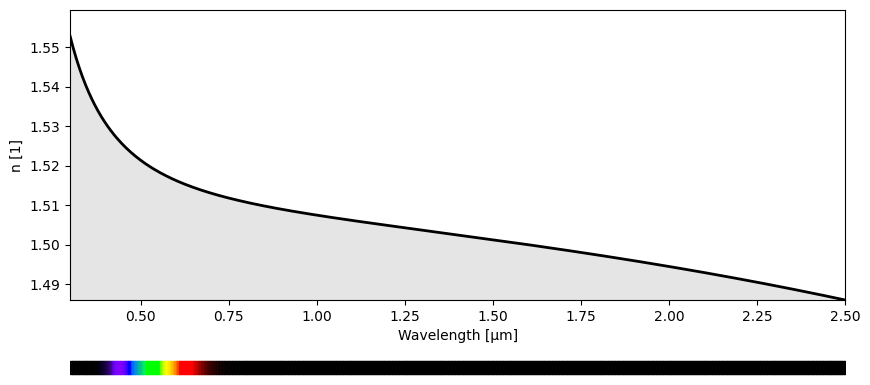

In [14]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import diffinytrace as dit
import torch
import numpy as np
torch.set_default_dtype(torch.float64)

aperture_radius = 12.7
NBK7 = dit.materials["NBK7"]
dit.plotting.wavelength.plot(NBK7)


In [15]:
n_enviroment = 1.000293
wave_len = 0.5328

lens_pos1D = 0.5
lens_thickness = 6.5
curvature = 0.05
detector_distance = 25.

grid_size = 32


light_transform = dit.transforms.Offset(torch.tensor([0.0,0.0,0.0]))
light_source = dit.source.CollimatedMonochromatic(light_transform,aperture_radius,wave_len)
light_transform.pos.requires_grad = False

lens_transform = dit.transforms.Distance(lens_pos1D,parent_transform=light_transform)
lens_transform.distance.requires_grad = False
surface1 = dit.Aspheric(curvature=curvature)
surface2 = dit.Plane()
lens1 = dit.Lens(lens_transform,lens_thickness,surface1,surface2,NBK7,aperture_radius)
lens1.lens_thickness.requires_grad = False

detector_transform = dit.transforms.Distance(detector_distance)#25.0+0.5
detector_transform.distance.requires_grad = False
plane_surface = dit.Plane()

aperture_radius_det = aperture_radius*0.5
detector = dit.Detector(detector_transform,plane_surface,aperture_radius_det)
gridxt = torch.linspace(-aperture_radius,aperture_radius,grid_size)
grid_delta =gridxt[1]-gridxt[0] 
grid_delta


system = dit.SequentialOpticalSystem({"source":light_source,"lens":lens1,"detector":detector})

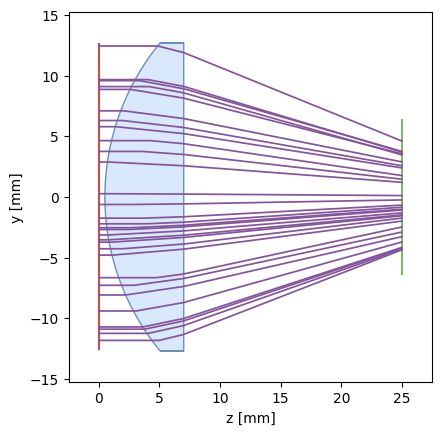

In [16]:

x,weights = light_source.sample(30)
sequence = ["source","lens","detector"]
O,D,wave_len,_,RayPaths = system(x,sequence)


dit.plotting.system2D.plot(system,RayPaths)


In [17]:

x,weights = light_source.sample(30)
sequence = ["source","lens","detector"]
O,D,wave_len,_,RayPaths = system(x,sequence)


dit.plotting.system3D.plot(system,RayPaths,show_grid=False)


In [18]:
irrs = []
sigmas = [0.01,0.05,0.1]
for sigma in sigmas:
    smoother = dit.nonimaging.smoothing.GaussianSmootherSquare(aperture_radius_det,256,sigma)
    irr = dit.render.smoothed_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,smoother=smoother,num_rays=100000,method_ray_tracing="monte_carlo")
    #dit.plotting.quantity2D.intensity(irr,f"irradiance ($\sigma$={smoother.sigma} mm)",[-aperture_radius,aperture_radius])
    irrs.append(irr)

In [19]:
from image_helper import image_from_grid
rows_extent = [[-aperture_radius, aperture_radius, -aperture_radius, aperture_radius]] * len(sigmas)
irrs = [np.clip(irr,0.0,0.03) for irr in irrs]

image_grid = [irrs]
rows_vidx = [0]
rows_cmap = ["jet"]
cbar_titles = ["[W/m²]"]
columns_title = [f"σ={sigma} mm" for sigma in sigmas]
rows_title = ["Smoothed Irradiance"]
kwargs = dict(image_grid=image_grid,
                rows_extent=rows_extent,
                rows_vidx=rows_vidx,
                rows_cmap=rows_cmap,
                rows_title=rows_title,
                cbar_titles=cbar_titles,
                columns_title=columns_title)
        
out = image_from_grid(**kwargs,
                                max_num_column=5,
                            font_size_PIL=35,
                            cbar_labelsize=20,
                            cbar_title_fontsize=20)
out = out[0]

_image_from_grid 1 3


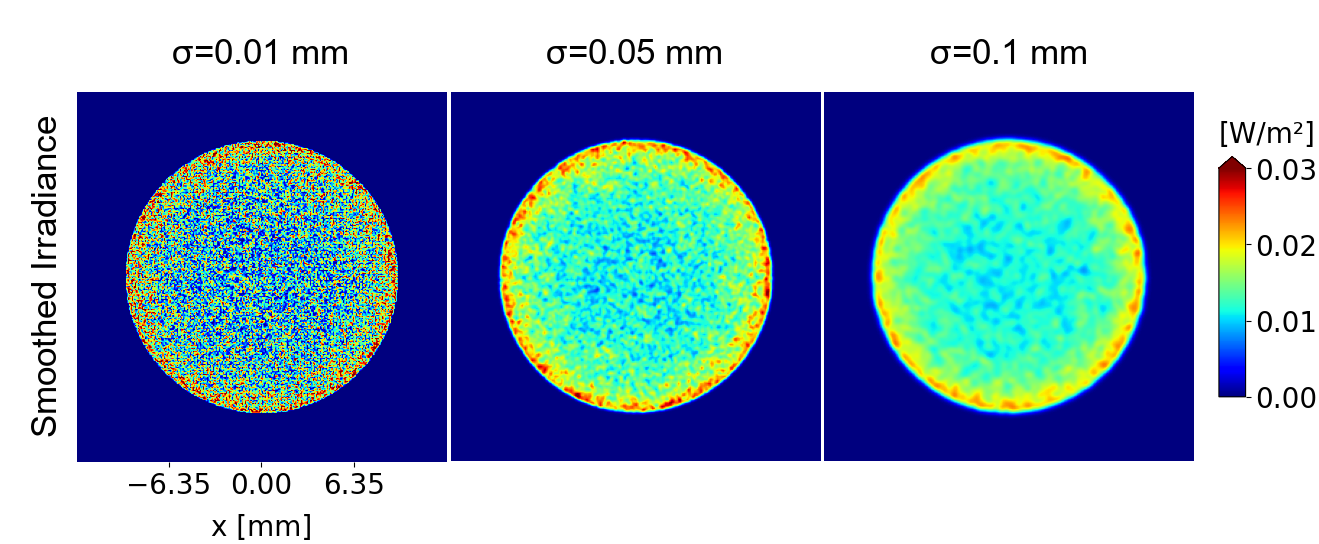

In [20]:
from PIL import Image, ImageDraw, ImageFont
original_image = Image.open(out)
original_image
    
